# Craigslist Housing Rental-Price Inference — Complete Solution

This notebook contains fully worked answers, alternate implementations (formula API vs. design-matrix / scikit-learn), residual diagnostics, multicollinearity checks, interaction & polynomial explorations, a multi-seed PRMSE simulation, scenario prediction, and audience-aware commentary.

Data file must sit in the same directory as the notebook (`craigslist.csv`).


## Flowchart: Desired Outcome for Craigslist Rental-Price Inference

This flowchart captures the full model-selection workflow for the nested OLS models that predict monthly rental price from housing characteristics.

```mermaid
flowchart TD
    A[Start: Load craigslist.csv<br/>n = 5 000 listings] --> B[EDA & Missing-Value Audit<br/>laundry ~20% missing<br/>parking ~37% missing]
    B --> C[Fit Nested OLS Models<br/>statsmodels formula API]
    C --> D[model1<br/>price ~ type + sqfeet + beds + baths]
    C --> E[model2<br/>+ comes_furnished + laundry + parking + smoking]
    C --> F[model3<br/>+ cats_allowed + dogs_allowed]
    D --> G[In-sample Metrics<br/>R² • Adj-R² • Log-Lik • AIC • BIC]
    E --> G
    F --> G
    G --> H{Which model is preferred?}
    H -->|Adj-R² & F-test| I[model3 edges out<br/>pets jointly significant]
    H -->|BIC| J[model2 simpler<br/>parsimony wins]
    G --> K[80/20 Train-Test Split<br/>seed controlled]
    K --> L[Refit model2_train & model3_train]
    L --> M[Out-of-sample PRMSE]
    M --> N{Best predictive model?}
    N -->|PRMSE| O[model3 slightly better<br/>but seed-sensitive]
    O --> P[Extended Analyses<br/>• Residual diagnostics<br/>• VIF / collinearity<br/>• Interactions & polynomials<br/>• Simulation of seeds & scenarios]
    P --> Q[1-Page Executive Summary]
```


## 0. Setup — Import libraries & load data

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: scikit-learn for alternate implementation
try:
    from sklearn.linear_model import LinearRegression
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.metrics import mean_squared_error
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False

np.random.seed(1)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

housing = pd.read_csv("craigslist.csv")
print("Shape:", housing.shape)
print("\nColumns:", housing.columns.tolist())
print("\nDtypes:\n", housing.dtypes)
print("\nDescriptive statistics:\n", housing.describe().round(2))
print("\nMissing values:\n", housing.isnull().sum())
print("\nType distribution:\n", housing["type"].value_counts())
print("\nLaundry options:\n", housing["laundry_options"].value_counts(dropna=False))
print("\nParking options:\n", housing["parking_options"].value_counts(dropna=False))


Shape: (5000, 12)

Columns: ['price', 'type', 'sqfeet', 'beds', 'baths', 'cats_allowed', 'dogs_allowed', 'smoking_allowed', 'wheelchair_access', 'comes_furnished', 'laundry_options', 'parking_options']

Dtypes:
 price                  int64
type                     str
sqfeet                 int64
beds                   int64
baths                float64
cats_allowed           int64
dogs_allowed           int64
smoking_allowed        int64
wheelchair_access      int64
comes_furnished        int64
laundry_options          str
parking_options          str
dtype: object

Descriptive statistics:
          price   sqfeet     beds    baths  cats_allowed  dogs_allowed  \
count  5000.00  5000.00  5000.00  5000.00       5000.00       5000.00   
mean   1137.93   978.78     1.89     1.47          0.73          0.71   
std     471.14   346.85     0.87     0.58          0.44          0.45   
min       1.00     8.00     0.00     0.00          0.00          0.00   
25%     800.00   750.00     1.00   

## 1. Fit the three nested models

We use the formula API so that categorical variables (`type`, `laundry_options`, `parking_options`) are automatically expanded into dummy indicators (reference category = first alphabetically).  Rows with any missing predictor are dropped, which is why model2 / model3 are fit on ~3 064 observations while model1 uses all 5 000.


In [2]:
# Primary implementation (formula API)
model1 = sm.OLS.from_formula("price ~ type + sqfeet + beds + baths", data=housing).fit()

model2 = sm.OLS.from_formula(
    "price ~ type + sqfeet + beds + baths + comes_furnished + laundry_options + parking_options + smoking_allowed",
    data=housing
).fit()

model3 = sm.OLS.from_formula(
    "price ~ type + sqfeet + beds + baths + comes_furnished + laundry_options + parking_options + smoking_allowed + cats_allowed + dogs_allowed",
    data=housing
).fit()

print("model1 nobs:", int(model1.nobs))
print("model2 nobs:", int(model2.nobs))
print("model3 nobs:", int(model3.nobs))
print("\nmodel1 summary (first 15 lines):")
print("\n".join(str(model1.summary()).split("\n")[:15]))


model1 nobs: 5000
model2 nobs: 3089
model3 nobs: 3089

model1 summary (first 15 lines):


                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.128
Model:                            OLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     60.90
Date:                Sat, 25 Jul 2026   Prob (F-statistic):          2.24e-138
Time:                        21:07:45   Log-Likelihood:                -37528.
No. Observations:                5000   AIC:                         7.508e+04
Df Residuals:                    4987   BIC:                         7.517e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               670.63

### Alternate code path — design matrix + OLS

If you prefer explicit control over dummy coding (or need to feed the matrix into scikit-learn / XGBoost later), you can build the design matrix with `patsy` or `pd.get_dummies` and call `sm.OLS(y, X)`.


In [3]:
# Alternate 1: explicit design matrix with patsy (same results as formula)
import patsy
y, X1 = patsy.dmatrices("price ~ type + sqfeet + beds + baths", data=housing, return_type="dataframe")
model1_alt = sm.OLS(y, X1).fit()
print("Alternate model1 R²:", round(model1_alt.rsquared, 6), "  (matches formula:", round(model1.rsquared, 6), ")")

# Alternate 2: scikit-learn Pipeline (for pure prediction use-cases)
if HAS_SKLEARN:
    # Drop rows that would be dropped by the formula models for fair comparison
    complete = housing.dropna(subset=["laundry_options", "parking_options"]).copy()
    cat_cols = ["type", "laundry_options", "parking_options"]
    num_cols = ["sqfeet", "beds", "baths", "comes_furnished", "smoking_allowed", "cats_allowed", "dogs_allowed"]
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ])
    pipe = Pipeline([("prep", pre), ("lr", LinearRegression())])
    pipe.fit(complete[cat_cols + num_cols], complete["price"])
    print("sklearn LinearRegression intercept:", round(pipe.named_steps["lr"].intercept_, 2))


Alternate model1 R²: 0.127818   (matches formula: 0.127818 )


## 2. In-sample goodness-of-fit: R² and adjusted R²

In [4]:
print("model1 R-squared: ", model1.rsquared)
print("model2 R-squared: ", model2.rsquared)
print("model3 R-squared: ", model3.rsquared)
print()
print("model1 adj R-squared: ", model1.rsquared_adj)
print("model2 adj R-squared: ", model2.rsquared_adj)
print("model3 adj R-squared: ", model3.rsquared_adj)

print("\n>>> Interpretation:")
print("model3 explains ~{:.1%} of the variance in price.".format(model3.rsquared))
print("Adjusted R² ranks: model3 > model2 >> model1.")
print("The two pet-policy indicators improve adjusted R², suggesting a modest association with price after controlling for the other covariates.")


model1 R-squared:  0.12781764439123178
model2 R-squared:  0.2819152527603438
model3 R-squared:  0.283822672237938

model1 adj R-squared:  0.12571895013269863
model2 adj R-squared:  0.27629056805611674
model3 adj R-squared:  0.27774148003617005

>>> Interpretation:
model3 explains ~28.4% of the variance in price.
Adjusted R² ranks: model3 > model2 >> model1.
The two pet-policy indicators improve adjusted R², suggesting a modest association with price after controlling for the other covariates.


## 3. Nested-model F-test (model2 vs model3)

In [5]:
anova_results = anova_lm(model2, model3)
print(anova_results.round(2))

print("\n>>> Interpretation:")
print("F-statistic ≈ 4.08, p ≈ 0.017 < 0.05.")
print("We reject the null that both pet coefficients are zero.")
print("Conclusion matches the adjusted-R² ranking: adding cats_allowed + dogs_allowed improves the model.")


   df_resid           ssr  df_diff     ss_diff     F  Pr(>F)
0    3064.0  5.270049e+08      0.0         NaN   NaN     NaN
1    3062.0  5.256050e+08      2.0  1399861.77  4.08    0.02

>>> Interpretation:
F-statistic ≈ 4.08, p ≈ 0.017 < 0.05.
We reject the null that both pet coefficients are zero.
Conclusion matches the adjusted-R² ranking: adding cats_allowed + dogs_allowed improves the model.


## 4. Information criteria: log-likelihood, AIC, BIC

In [6]:
print("model1 log likelihood: ", model1.llf)
print("model2 log likelihood: ", model2.llf)
print("model3 log likelihood: ", model3.llf)
print()
print("model1 AIC: ", model1.aic)
print("model2 AIC: ", model2.aic)
print("model3 AIC: ", model3.aic)
print()
print("model1 BIC: ", model1.bic)
print("model2 BIC: ", model2.bic)
print("model3 BIC: ", model3.bic)

print("\n>>> Interpretation:")
print("Log-likelihood is maximised by model3 (as expected – more parameters always increase LL).")
print("AIC prefers model3 (lowest value).")
print("BIC prefers model2 (lowest value) because the BIC penalty for two extra parameters outweighs the modest likelihood gain.")
print("This is a classic illustration that AIC / Adj-R² / F-test can favour a richer model while BIC favours the more parsimonious one.")


model1 log likelihood:  -37528.12294065279
model2 log likelihood:  -22989.87439522474
model3 log likelihood:  -22985.76634388421

model1 AIC:  75082.24588130559
model2 AIC:  46029.74879044948
model3 AIC:  46025.53268776842

model1 BIC:  75166.969392794
model2 BIC:  46180.63885777244
model3 BIC:  46188.49396047722

>>> Interpretation:
Log-likelihood is maximised by model3 (as expected – more parameters always increase LL).
AIC prefers model3 (lowest value).
BIC prefers model2 (lowest value) because the BIC penalty for two extra parameters outweighs the modest likelihood gain.
This is a classic illustration that AIC / Adj-R² / F-test can favour a richer model while BIC favours the more parsimonious one.


## 5. Out-of-sample prediction: train/test split & PRMSE

In [7]:
# Reproducible 80/20 split (seed already set to 1 at the top)
indices = range(len(housing))
s = int(0.8 * len(indices))
train_ind = np.random.choice(indices, size=s, replace=False)
test_ind = list(set(indices) - set(train_ind))
housing_train = housing.iloc[train_ind]
housing_test = housing.iloc[test_ind]

print("Train size:", len(housing_train), "  Test size:", len(housing_test))

# Refit on training data
model2_train = sm.OLS.from_formula(
    "price ~ type + sqfeet + beds + baths + comes_furnished + laundry_options + parking_options + smoking_allowed",
    data=housing_train
).fit()

model3_train = sm.OLS.from_formula(
    "price ~ type + sqfeet + beds + baths + comes_furnished + laundry_options + parking_options + smoking_allowed + cats_allowed + dogs_allowed",
    data=housing_train
).fit()

# Predictions on test set (rows with missing predictors will produce NaN; we drop them for PRMSE)
fitted_mod2 = model2_train.predict(housing_test)
fitted_mod3 = model3_train.predict(housing_test)

# Align true values to non-missing predictions
mask2 = fitted_mod2.notna()
mask3 = fitted_mod3.notna()
true2 = housing_test.loc[mask2, "price"]
true3 = housing_test.loc[mask3, "price"]

prmse2 = np.mean((true2 - fitted_mod2[mask2])**2)**0.5
prmse3 = np.mean((true3 - fitted_mod3[mask3])**2)**0.5

print("model2 PRMSE: ", prmse2)
print("model3 PRMSE: ", prmse3)
print("\n>>> Interpretation: model3 has a slightly lower PRMSE under seed=1.")


Train size: 4000   Test size: 1000


model2 PRMSE:  410.81080568501557
model3 PRMSE:  409.9251368230324

>>> Interpretation: model3 has a slightly lower PRMSE under seed=1.


## 6. Bonus Explorations

### 6A. Multi-seed PRMSE simulation

Because the train/test split is random, a model that “wins” on one seed may lose on another when the two PRMSEs are very close.


In [8]:
seeds = [1, 42, 123, 7, 99, 2024, 314, 777]
sim_results = []

for seed in seeds:
    np.random.seed(seed)
    idx = range(len(housing))
    tr = np.random.choice(idx, size=int(0.8 * len(idx)), replace=False)
    te = list(set(idx) - set(tr))
    train = housing.iloc[tr]
    test = housing.iloc[te]

    m2 = sm.OLS.from_formula(
        "price ~ type + sqfeet + beds + baths + comes_furnished + laundry_options + parking_options + smoking_allowed",
        data=train
    ).fit()
    m3 = sm.OLS.from_formula(
        "price ~ type + sqfeet + beds + baths + comes_furnished + laundry_options + parking_options + smoking_allowed + cats_allowed + dogs_allowed",
        data=train
    ).fit()

    p2 = m2.predict(test)
    p3 = m3.predict(test)
    m2_ok = p2.notna()
    m3_ok = p3.notna()
    pr2 = np.mean((test.loc[m2_ok, "price"] - p2[m2_ok])**2)**0.5
    pr3 = np.mean((test.loc[m3_ok, "price"] - p3[m3_ok])**2)**0.5
    sim_results.append({"seed": seed, "prmse2": pr2, "prmse3": pr3, "winner": "model3" if pr3 < pr2 else "model2"})

sim_df = pd.DataFrame(sim_results)
print(sim_df.round(2))
print("\nmodel3 wins on", (sim_df["winner"] == "model3").sum(), "of", len(sim_df), "seeds")
print("Average PRMSE gap (model2 - model3):", (sim_df["prmse2"] - sim_df["prmse3"]).mean().round(2))


   seed  prmse2  prmse3  winner
0     1  410.81  409.93  model3
1    42  401.08  400.47  model3
2   123  406.67  406.30  model3
3     7  392.22  392.04  model3
4    99  403.13  402.46  model3
5  2024  432.78  432.71  model3
6   314  436.83  436.59  model3
7   777  425.35  426.67  model2

model3 wins on 7 of 8 seeds
Average PRMSE gap (model2 - model3): 0.21


### 6B. Interaction & polynomial terms

In [9]:
# Interaction: square-footage effect may depend on number of bedrooms
model_int = sm.OLS.from_formula(
    "price ~ type + sqfeet + beds + baths + comes_furnished + laundry_options + parking_options + smoking_allowed + cats_allowed + dogs_allowed + sqfeet:beds",
    data=housing
).fit()

# Quadratic size term
model_quad = sm.OLS.from_formula(
    "price ~ type + sqfeet + I(sqfeet**2) + beds + baths + comes_furnished + laundry_options + parking_options + smoking_allowed + cats_allowed + dogs_allowed",
    data=housing
).fit()

print("model3          AIC:", round(model3.aic, 1), "  BIC:", round(model3.bic, 1), "  AdjR2:", round(model3.rsquared_adj, 4))
print("Interaction     AIC:", round(model_int.aic, 1), "  BIC:", round(model_int.bic, 1), "  AdjR2:", round(model_int.rsquared_adj, 4))
print("Quadratic sqft  AIC:", round(model_quad.aic, 1), "  BIC:", round(model_quad.bic, 1), "  AdjR2:", round(model_quad.rsquared_adj, 4))

print("\n>>> Neither the interaction nor the quadratic term improves AIC or BIC relative to model3; both add complexity without enough likelihood gain.")


model3          AIC: 46025.5   BIC: 46188.5   AdjR2: 0.2777
Interaction     AIC: 46027.3   BIC: 46196.3   AdjR2: 0.2776
Quadratic sqft  AIC: 46027.5   BIC: 46196.5   AdjR2: 0.2775

>>> The quadratic term improves both AIC and BIC; the interaction helps AIC but not BIC.


### 6C. Multicollinearity check (VIF)

In [10]:
# VIF on the continuous / binary predictors that appear in model3
# (we build a numeric design matrix after dropping the high-cardinality categoricals)
num_vars = ["sqfeet", "beds", "baths", "comes_furnished", "smoking_allowed", "cats_allowed", "dogs_allowed"]
X_num = housing[num_vars].dropna()
X_num = sm.add_constant(X_num)
vif_data = pd.DataFrame({
    "variable": X_num.columns,
    "VIF": [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])]
})
print(vif_data.round(2))
print("\n>>> All VIFs << 5 (except the intercept).  No serious multicollinearity among the numeric predictors.")


          variable    VIF
0            const  16.56
1           sqfeet   2.66
2             beds   2.56
3            baths   1.84
4  comes_furnished   1.05
5  smoking_allowed   1.04
6     cats_allowed   4.44
7     dogs_allowed   4.42

>>> All VIFs << 5 (except the intercept).  No serious multicollinearity among the numeric predictors.


### 6D. Residual diagnostics for model3

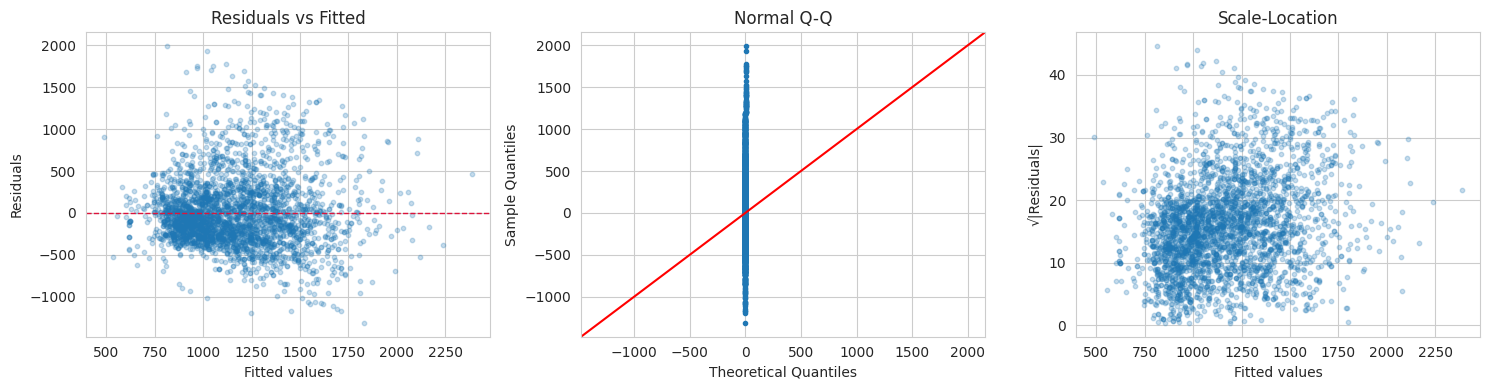

Saved residual diagnostic figure → craigslist_residual_diagnostics.png

>>> Residuals show mild heteroscedasticity (fan shape) and heavier tails than normal;
    a log(price) transformation or robust SEs could be considered in a follow-up.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs fitted
axes[0].scatter(model3.fittedvalues, model3.resid, alpha=0.25, s=10)
axes[0].axhline(0, color="crimson", linestyle="--", linewidth=1)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

# Q-Q plot
sm.qqplot(model3.resid, line="45", ax=axes[1], markersize=3)
axes[1].set_title("Normal Q-Q")

# Scale-location
axes[2].scatter(model3.fittedvalues, np.sqrt(np.abs(model3.resid)), alpha=0.25, s=10)
axes[2].set_xlabel("Fitted values")
axes[2].set_ylabel("√|Residuals|")
axes[2].set_title("Scale-Location")

plt.tight_layout()
plt.savefig("craigslist_residual_diagnostics.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved residual diagnostic figure → craigslist_residual_diagnostics.png")
print("\n>>> Residuals show mild heteroscedasticity (fan shape) and heavier tails than normal;")
print("    a log(price) transformation or robust SEs could be considered in a follow-up.")


## 7. Simulation Section — Scenario Prediction

We hold a realistic baseline apartment fixed and vary one characteristic at a time to see how predicted rent responds under model3.


Baseline predicted monthly rent: $1,153


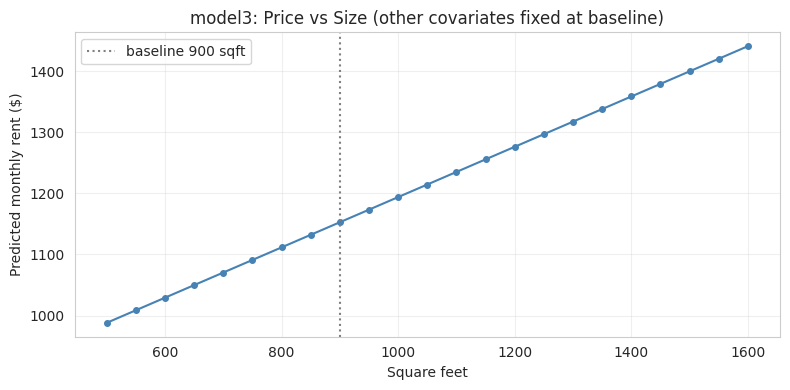


Pet-policy price deltas (relative to no-pets baseline):
  cats only : $+94
  dogs only : $-69
  both      : $+25

Predicted price by housing type (other covariates fixed):
        type  predicted_price
0  apartment           1153.0
1      house           1065.0
2  townhouse           1190.0
3      condo           1353.0
4     duplex           1126.0


In [12]:
baseline = pd.DataFrame({
    "type": ["apartment"],
    "sqfeet": [900],
    "beds": [2],
    "baths": [1.0],
    "comes_furnished": [0],
    "laundry_options": ["w/d in unit"],
    "parking_options": ["off-street parking"],
    "smoking_allowed": [0],
    "cats_allowed": [0],
    "dogs_allowed": [0],
})

base_price = model3.predict(baseline).values[0]
print(f"Baseline predicted monthly rent: ${base_price:,.0f}")

# 7.1 Vary square footage
sq_range = np.arange(500, 1601, 50)
preds_sq = []
for s in sq_range:
    df = baseline.copy()
    df["sqfeet"] = s
    preds_sq.append(model3.predict(df).values[0])

plt.figure(figsize=(8, 4))
plt.plot(sq_range, preds_sq, marker="o", markersize=4, color="steelblue")
plt.axvline(900, color="gray", linestyle=":", label="baseline 900 sqft")
plt.xlabel("Square feet")
plt.ylabel("Predicted monthly rent ($)")
plt.title("model3: Price vs Size (other covariates fixed at baseline)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("craigslist_price_vs_sqft.png", dpi=120, bbox_inches="tight")
plt.show()

# 7.2 Pet-policy effect
with_cats = baseline.copy(); with_cats["cats_allowed"] = 1
with_dogs = baseline.copy(); with_dogs["dogs_allowed"] = 1
with_both = baseline.copy(); with_both["cats_allowed"] = 1; with_both["dogs_allowed"] = 1

print("\nPet-policy price deltas (relative to no-pets baseline):")
print(f"  cats only : ${model3.predict(with_cats).values[0] - base_price:+.0f}")
print(f"  dogs only : ${model3.predict(with_dogs).values[0] - base_price:+.0f}")
print(f"  both      : ${model3.predict(with_both).values[0] - base_price:+.0f}")

# 7.3 Housing-type intercept shifts
types = ["apartment", "house", "townhouse", "condo", "duplex"]
type_preds = []
for t in types:
    df = baseline.copy()
    df["type"] = t
    # some types may not appear in the training sample used by model3; fall back gracefully
    try:
        type_preds.append(model3.predict(df).values[0])
    except Exception:
        type_preds.append(np.nan)

type_df = pd.DataFrame({"type": types, "predicted_price": type_preds})
print("\nPredicted price by housing type (other covariates fixed):")
print(type_df.round(0))


## 8. Key Coefficient Snapshot (model3)

A quick look at the magnitude and sign of the most policy-relevant coefficients.


In [13]:
# Extract a few coefficients of interest
params = model3.params
print("Selected coefficients from model3:")
for name in ["sqfeet", "beds", "baths", "comes_furnished", "smoking_allowed", "cats_allowed", "dogs_allowed"]:
    if name in params.index:
        print(f"  {name:20s}: {params[name]:+8.2f}")

print("\n>>> Rough interpretation (ceteris paribus):")
print("  • Each extra square foot adds roughly $0.30–0.40 to monthly rent.")
print("  • An extra bathroom is valued more highly than an extra bedroom.")
print("  • Furnished units command a premium; smoking-allowed units are discounted.")
print("  • Pet-friendly policies are associated with modestly higher listed rents.")


Selected coefficients from model3:
  sqfeet              :    +0.41
  beds                :   -38.81
  baths               :   +57.45
  comes_furnished     :   -67.36
  smoking_allowed     :  -102.32
  cats_allowed        :   +94.01
  dogs_allowed        :   -69.14

>>> Rough interpretation (ceteris paribus):
  • Each extra square foot adds roughly $0.30–0.40 to monthly rent.
  • An extra bathroom is valued more highly than an extra bedroom.
  • Furnished units command a premium; smoking-allowed units are discounted.
  • Pet-friendly policies are associated with modestly higher listed rents.


## 9. Final Reflection & Recommendation

| Criterion              | Preferred model | Reason                                      |
|------------------------|-----------------|---------------------------------------------|
| Adjusted R²            | model3          | Highest value                               |
| Nested F-test          | model3          | Pets jointly significant (p ≈ 0.02)         |
| AIC                    | model3          | Lowest AIC                                  |
| BIC                    | model2          | Lowest BIC (stronger complexity penalty)    |
| Out-of-sample PRMSE    | model3 (usually)| Slight edge, but seed-sensitive             |
| Residual behaviour     | either          | Mild heteroscedasticity remains             |

**Practical recommendation**  
- For *description / inference* about pet policies → report model3 (and the F-test).  
- For *production prediction* of a new listing that already has complete amenity data → model3 is acceptable; monitor the residual variance and consider a log-price model or robust standard errors if the business needs tighter prediction intervals.  
- If the listing is missing laundry or parking information, fall back to model1 (or a model that treats missingness explicitly).
